In [1]:
!pip -q install pytorch-tabnet==4.1.0 scikit-learn==1.5.2 pandas==2.2.2 matplotlib==3.9.2


[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Escolha do dataset: "covtype" (Forest Cover) ou "adult"
DATASET = "covtype"  # "covtype" ou "adult"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch, random, os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from pytorch_tabnet.tab_model import TabNetClassifier

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("CUDA disponível?", torch.cuda.is_available())
print("Dataset selecionado:", DATASET)

CUDA disponível? False
Dataset selecionado: covtype


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype, fetch_openml

def load_covtype():
    cov = fetch_covtype(as_frame=True)
    X = cov.data
    y = cov.target.values - 1  # classes 0..6

    # Split: treino/val/test estratificados
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )

    # Padronização (numérico)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)
    X_test  = scaler.transform(X_test)

    # Converte para numpy float32/int64
    X_train = X_train.astype(np.float32)
    X_valid = X_valid.astype(np.float32)
    X_test  = X_test.astype(np.float32)

    y_train = y_train.astype(np.int64)
    y_valid = y_valid.astype(np.int64)
    y_test  = y_test.astype(np.int64)

    feat_names = cov.data.columns.tolist()
    return X_train, X_valid, X_test, y_train, y_valid, y_test, feat_names

def load_adult():
    # Adult tem variáveis categóricas → one-hot no train e reindex nos splits
    adult = fetch_openml(name='adult', version=2, as_frame=True)
    X = adult.data
    y = adult.target

    # Apaga linhas com NA (comum em 'workclass', 'occupation' etc.)
    data = pd.concat([X, y], axis=1).dropna()
    X = data.drop(columns=[adult.target.name])
    y = data[adult.target.name]

    # Converte target para 0/1
    y = (y == ">50K").astype(int).values

    # Split
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )

    # One-hot no train (fit) e alinha colunas no valid/test
    X_train_oh = pd.get_dummies(X_train, drop_first=False)
    valid_oh   = pd.get_dummies(X_valid, drop_first=False)
    test_oh    = pd.get_dummies(X_test, drop_first=False)

    # Alinha colunas (reindex) para evitar mismatch
    X_valid_oh = valid_oh.reindex(columns=X_train_oh.columns, fill_value=0)
    X_test_oh  = test_oh.reindex(columns=X_train_oh.columns, fill_value=0)

    # Padronização opcional (já é one-hot + numérico)
    scaler = StandardScaler(with_mean=False)  # esparso-friendly; mas aqui teremos denso
    X_train_np = scaler.fit_transform(X_train_oh.values).astype(np.float32)
    X_valid_np = scaler.transform(X_valid_oh.values).astype(np.float32)
    X_test_np  = scaler.transform(X_test_oh.values).astype(np.float32)

    y_train = y_train.astype(np.int64)
    y_valid = y_valid.astype(np.int64)
    y_test  = y_test.astype(np.int64)

    feat_names = X_train_oh.columns.tolist()
    return X_train_np, X_valid_np, X_test_np, y_train, y_valid, y_test, feat_names

if DATASET == "covtype":
    X_train_np, X_valid_np, X_test_np, y_train_np, y_valid_np, y_test_np, feat_names = load_covtype()
elif DATASET == "adult":
    X_train_np, X_valid_np, X_test_np, y_train_np, y_valid_np, y_test_np, feat_names = load_adult()
else:
    raise ValueError("DATASET deve ser 'covtype' ou 'adult'.")

print("Shapes:", X_train_np.shape, X_valid_np.shape, X_test_np.shape)
print("Ex.: n_features =", len(feat_names))

Shapes: (371847, 54) (92962, 54) (116203, 54)
Ex.: n_features = 54


In [4]:
from pytorch_tabnet.tab_model import TabNetClassifier

clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    n_independent=2, n_shared=2,
    seed=42,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type="sparsemax",   # interpretável
    verbose=10
)

clf.fit(
    X_train_np, y_train_np,
    eval_set=[(X_valid_np, y_valid_np)],
    eval_name=["valid"],
    eval_metric=["accuracy"],
    max_epochs=100,
    patience=15,
    batch_size=8192 if X_train_np.shape[0] > 10000 else 2048,  # ajusta p/ Adult
    virtual_batch_size=256,
    num_workers=0,
    drop_last=False
)

c:\Users\Tulio Volpato\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.06462 | valid_accuracy: 0.68579 |  0:00:38s
epoch 10 | loss: 0.51886 | valid_accuracy: 0.79198 |  0:07:13s
epoch 20 | loss: 0.41675 | valid_accuracy: 0.83814 |  0:13:33s
epoch 30 | loss: 0.32664 | valid_accuracy: 0.87627 |  0:19:44s
epoch 40 | loss: 0.27073 | valid_accuracy: 0.90083 |  0:26:31s
epoch 50 | loss: 0.24466 | valid_accuracy: 0.91154 |  0:33:16s
epoch 60 | loss: 0.23014 | valid_accuracy: 0.91401 |  0:39:39s
epoch 70 | loss: 0.2048  | valid_accuracy: 0.92601 |  0:46:21s
epoch 80 | loss: 0.19612 | valid_accuracy: 0.92987 |  0:53:00s
epoch 90 | loss: 0.1839  | valid_accuracy: 0.93324 |  0:59:40s
Stop training because you reached max_epochs = 100 with best_epoch = 97 and best_valid_accuracy = 0.93605


c:\Users\Tulio Volpato\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [5]:
y_pred = clf.predict(X_test_np)
acc = accuracy_score(y_test_np, y_pred)
print(f"Accuracy (teste): {acc:.4f}")

print("\nRelatório de classificação:\n")
print(classification_report(y_test_np, y_pred, digits=4))

Accuracy (teste): 0.9354

Relatório de classificação:

              precision    recall  f1-score   support

           0     0.9384    0.9291    0.9337     42368
           1     0.9407    0.9498    0.9453     56661
           2     0.9279    0.9339    0.9309      7151
           3     0.8223    0.8342    0.8282       549
           4     0.8371    0.7657    0.7998      1899
           5     0.8892    0.8762    0.8827      3473
           6     0.9381    0.9454    0.9417      4102

    accuracy                         0.9354    116203
   macro avg     0.8991    0.8906    0.8946    116203
weighted avg     0.9352    0.9354    0.9352    116203



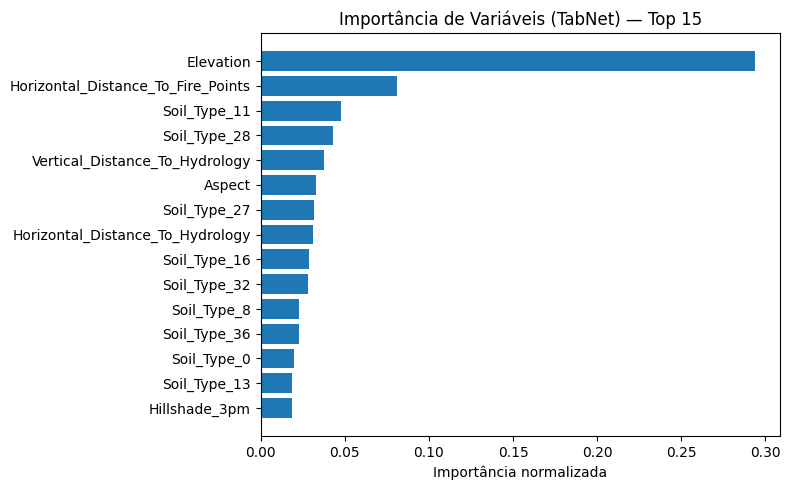

,feature,importance
0,Elevation,0.293976
9,Horizontal_Distance_To_Fire_Points,0.081240
25,Soil_Type_11,0.048013
42,Soil_Type_28,0.043028
4,Vertical_Distance_To_Hydrology,0.037836
1,Aspect,0.032679
41,Soil_Type_27,0.031812
3,Horizontal_Distance_To_Hydrology,0.030781
30,Soil_Type_16,0.028467
46,Soil_Type_32,0.028160


In [6]:
feat_importances = clf.feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": feat_importances})
imp_df = imp_df.sort_values("importance", ascending=False)

TOPK = 15
top_df = imp_df.head(TOPK)

plt.figure(figsize=(8,5))
plt.barh(top_df["feature"][::-1], top_df["importance"][::-1])
plt.title("Importância de Variáveis (TabNet) — Top {}".format(TOPK))
plt.xlabel("Importância normalizada")
plt.tight_layout()
plt.show()

top_df.head(10)

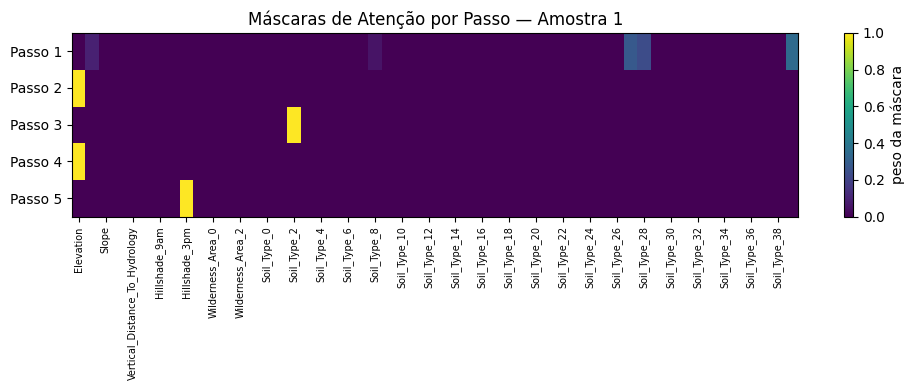

In [7]:
# Explicação de um pequeno lote
explain_matrix, masks = clf.explain(X_test_np[:64])

# Seleciona uma amostra para visualizar
sample_idx = 0
steps = len(masks)
A = np.stack([masks[i][sample_idx] for i in range(steps)], axis=0)  # (steps, n_features)

plt.figure(figsize=(10,4))
plt.imshow(A, aspect="auto")
plt.colorbar(label="peso da máscara")
plt.yticks(range(steps), [f"Passo {i+1}" for i in range(steps)])
# Para muitos atributos (Adult), rotaciona e reduz ticks
if len(feat_names) <= 40:
    plt.xticks(range(len(feat_names)), feat_names, rotation=90, fontsize=8)
else:
    skip = max(1, len(feat_names)//20)
    positions = list(range(0, len(feat_names), skip))
    labels = [feat_names[i] for i in positions]
    plt.xticks(positions, labels, rotation=90, fontsize=7)

plt.title("Máscaras de Atenção por Passo — Amostra 1")
plt.tight_layout()
plt.show()

In [8]:
from pytorch_tabnet.pretraining import TabNetPretrainer

pretrainer = TabNetPretrainer(
    n_d=32, n_a=32, n_steps=5, gamma=1.5,
    lambda_sparse=1e-4,
    n_independent=2, n_shared=2,
    seed=42, mask_type="sparsemax",
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=10
)

pretrainer.fit(
    X_train_np, eval_set=[X_valid_np],
    max_epochs=100, patience=15,
    batch_size=8192 if X_train_np.shape[0] > 10000 else 2048,
    virtual_batch_size=256,
    num_workers=0, drop_last=False
)

clf_pt = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5, gamma=1.5,
    lambda_sparse=1e-4, n_independent=2, n_shared=2,
    seed=42, mask_type="sparsemax",
    optimizer_params=dict(lr=1e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=10
)

clf_pt.fit(
    X_train_np, y_train_np,
    eval_set=[(X_valid_np, y_valid_np)],
    eval_name=["valid"], eval_metric=["accuracy"],
    max_epochs=100, patience=15,
    batch_size=8192 if X_train_np.shape[0] > 10000 else 2048,
    virtual_batch_size=256,
    from_unsupervised=pretrainer
)

y_pred_pt = clf_pt.predict(X_test_np)
print("Accuracy (teste) com pré-treino:", accuracy_score(y_test_np, y_pred_pt))

c:\Users\Tulio Volpato\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: -195853.00152| val_0_unsup_loss_numpy: 245880703680512.0|  0:00:49s
epoch 10 | loss: -17560660250.4112| val_0_unsup_loss_numpy: 5.084842815450094e+19|  0:08:21s

Early stopping occurred at epoch 15 with best_epoch = 0 and best_val_0_unsup_loss_numpy = 245880703680512.0


c:\Users\Tulio Volpato\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
c:\Users\Tulio Volpato\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
c:\Users\Tulio Volpato\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 1.32523 | valid_accuracy: 0.60187 |  0:00:35s
epoch 10 | loss: 0.61574 | valid_accuracy: 0.73938 |  0:06:57s
epoch 20 | loss: 0.54036 | valid_accuracy: 0.77915 |  0:12:55s
epoch 30 | loss: 0.49956 | valid_accuracy: 0.80012 |  0:18:45s
epoch 40 | loss: 0.48583 | valid_accuracy: 0.80665 |  0:24:35s
epoch 50 | loss: 0.43894 | valid_accuracy: 0.82693 |  0:30:25s
epoch 60 | loss: 0.40892 | valid_accuracy: 0.84283 |  0:36:11s
epoch 70 | loss: 0.35936 | valid_accuracy: 0.86112 |  0:41:57s
epoch 80 | loss: 0.34703 | valid_accuracy: 0.8684  |  0:47:38s
epoch 90 | loss: 0.316   | valid_accuracy: 0.87872 |  0:54:18s
Stop training because you reached max_epochs = 100 with best_epoch = 98 and best_valid_accuracy = 0.88539


c:\Users\Tulio Volpato\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Accuracy (teste) com pré-treino: 0.8857860812543566
